# Sarcasm-Aware Question Duplicate Detection

This notebook refactors an **NLP + modeling workflow** to detect whether two questions are duplicates while accounting for sarcasm.


In [ ]:
import re
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset as HFDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

import nltk
import torch
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, wordpunct_tokenize

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

for pkg in ["punkt", "punkt_tab", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

sns.set_style("whitegrid")

## 1) Load Original Datasets (No Dataset Replacement)

- **Quora Question Pairs** for duplicate detection.
- **CreativeLang/SARC_Sarcasm** for sarcasm detection.


In [ ]:
# Quora duplicates
quora_raw = load_dataset("sentence-transformers/quora-duplicates", "pair-class", split="train")
quora_df = quora_raw.to_pandas().rename(
    columns={"sentence1": "question1", "sentence2": "question2", "label": "is_duplicate"}
)
quora_df = quora_df[["question1", "question2", "is_duplicate"]].dropna()

# Sarcasm dataset
sarcasm_raw = load_dataset("CreativeLang/SARC_Sarcasm", split="train")
sarcasm_df = sarcasm_raw.to_pandas()

# Build a stronger weak-supervision sarcasm score from original SARC fields.
# This avoids the extreme class collapse from a single hard threshold.
sarcasm_df = sarcasm_df[["text", "ups", "downs", "score"]].dropna().copy()
sarcasm_df["text"] = sarcasm_df["text"].astype(str)
sarcasm_df = sarcasm_df[sarcasm_df["text"].str.len() >= 8]

ratio = sarcasm_df["downs"] / (sarcasm_df["ups"] + 1.0)
controversy = (sarcasm_df["downs"] > sarcasm_df["ups"]).astype(float)
cue_regex = r"\b(yeah right|as if|sure\b|totally|obviously|great job|nice|wow|brilliant)\b|/s"
sarcasm_cue = sarcasm_df["text"].str.lower().str.contains(cue_regex, regex=True).astype(float)

# Rank-based normalization is robust to heavy-tail vote distributions.
ratio_rank = ratio.rank(pct=True)
score_rank = sarcasm_df["score"].abs().rank(pct=True)
sarcasm_df["weak_sarc_score"] = 0.65 * ratio_rank + 0.25 * controversy + 0.10 * sarcasm_cue

# Balanced labeling from extremes of weak sarcasm score.
pos_pool = sarcasm_df.nlargest(60000, "weak_sarc_score")
neg_pool = sarcasm_df.nsmallest(60000, "weak_sarc_score")

n_each = 20000
pos = pos_pool.sample(n=min(n_each, len(pos_pool)), random_state=SEED).copy()
neg = neg_pool.sample(n=min(n_each, len(neg_pool)), random_state=SEED).copy()
pos["label"] = 1
neg["label"] = 0
sarcasm_df = pd.concat([pos, neg], axis=0).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
sarcasm_df = sarcasm_df[["text", "label"]]

# Practical subset size for Quora speed
quora_df = quora_df.sample(n=min(35000, len(quora_df)), random_state=SEED)

print("Quora shape:", quora_df.shape)
print(quora_df["is_duplicate"].value_counts(dropna=False))
print("\nSarcasm shape:", sarcasm_df.shape)
print(sarcasm_df["label"].value_counts(dropna=False))

README.md: 0.00B [00:00, ?B/s]

pair-class/train-00000-of-00001.parquet:   0%|          | 0.00/35.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/404290 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b43fbca2a8c485(…):   0%|          | 0.00/243M [00:00<?, ?B/s]

data/train-00001-of-00004-b1fddb107de47f(…):   0%|          | 0.00/222M [00:00<?, ?B/s]

data/train-00002-of-00004-cb113ea4aa4e1c(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

data/train-00003-of-00004-04fddff88acd7c(…):   0%|          | 0.00/220M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12704751 [00:00<?, ? examples/s]

Quora shape: (35000, 3)
is_duplicate
0    22122
1    12878
Name: count, dtype: int64

Sarcasm shape: (40000, 2)
label
0    20000
1    20000
Name: count, dtype: int64


## 2) NLP Preprocessing, Tokenization, and Feature Engineering

- **TF-IDF Cosine Similarity**: captures lexical-semantic overlap in sparse vector space.
- **Jaccard Similarity**: robust set-overlap metric for wording overlap.
- **Length/Surface Features**: useful for stylistic mismatch detection.
- **Negation mismatch**: practical sarcasm-sensitive proxy (semantic flips via "not", "never", etc.).

In [ ]:
lemmatizer = WordNetLemmatizer()
NEGATIONS = {"not", "never", "no", "n't", "none", "nobody", "nothing"}

def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text: str):
    text = clean_text(text)
    try:
        tokens = word_tokenize(text)
    except LookupError:
        # Fallback tokenizer avoids hard failure if punkt resources are missing.
        tokens = wordpunct_tokenize(text)
    toks = [lemmatizer.lemmatize(t) for t in tokens if t.strip()]
    return toks

def jaccard_similarity(t1, t2):
    s1, s2 = set(t1), set(t2)
    if not s1 and not s2:
        return 1.0
    return len(s1 & s2) / max(len(s1 | s2), 1)

def negation_flag(tokens):
    return int(any(t in NEGATIONS for t in tokens))

def build_pair_features(df):
    q1_clean = df["question1"].astype(str).map(clean_text)
    q2_clean = df["question2"].astype(str).map(clean_text)

    q1_tok = q1_clean.map(preprocess_text)
    q2_tok = q2_clean.map(preprocess_text)

    # Shared TF-IDF space across both columns
    corpus = pd.concat([q1_clean, q2_clean], axis=0).tolist()
    tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000)
    tfidf.fit(corpus)

    q1_vec = tfidf.transform(q1_clean)
    q2_vec = tfidf.transform(q2_clean)
    cos = np.array([
        cosine_similarity(q1_vec[i], q2_vec[i])[0, 0] for i in range(q1_vec.shape[0])
    ])

    feats = pd.DataFrame({
        "cosine_tfidf": cos,
        "jaccard": [jaccard_similarity(a, b) for a, b in zip(q1_tok, q2_tok)],
        "len_diff": (q1_clean.str.len() - q2_clean.str.len()).abs(),
        "token_len_diff": (q1_tok.map(len) - q2_tok.map(len)).abs(),
        "neg_mismatch": (q1_tok.map(negation_flag) != q2_tok.map(negation_flag)).astype(int),
    })
    return feats, q1_clean, q2_clean

def balance_binary_df(df, label_col):
    major = df[df[label_col] == df[label_col].value_counts().idxmax()]
    minor = df[df[label_col] != df[label_col].value_counts().idxmax()]
    major_down = resample(major, replace=False, n_samples=len(minor), random_state=SEED)
    out = pd.concat([major_down, minor]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return out

## 3) Utility: Metrics + ROC Plotting

In [ ]:
@dataclass
class StageResult:
    stage: str
    y_true: np.ndarray
    y_pred: np.ndarray
    y_score: np.ndarray
    metrics: dict


def compute_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def plot_roc(y_true, y_score, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Stage 1: Duplicate Detection Only

Model: TF-IDF + engineered pair features + Logistic Regression.

Balancing: class-balanced training split (downsample majority class).

{'accuracy': 0.7144285714285714, 'precision': 0.5909807631661936, 'recall': 0.7274844720496895, 'f1': 0.6521663476596485, 'roc_auc': np.float64(0.7915198051565151)}


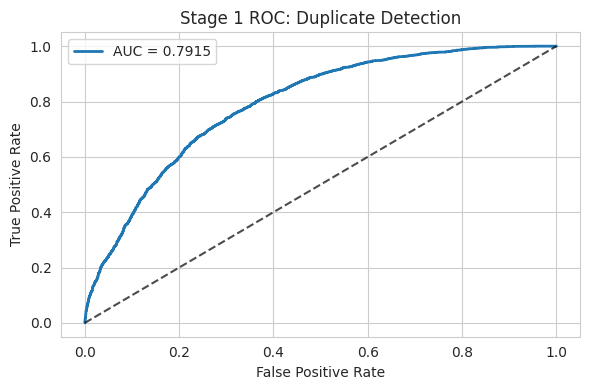

In [ ]:
# Train/test split (before balancing)
q_train, q_test = train_test_split(
    quora_df, test_size=0.2, random_state=SEED, stratify=quora_df["is_duplicate"]
)

# Balance train only
q_train_bal = balance_binary_df(q_train, "is_duplicate")

# Build features
X_train_fe, q1_train_clean, q2_train_clean = build_pair_features(q_train_bal)
X_test_fe, q1_test_clean, q2_test_clean = build_pair_features(q_test)

y_train_dup = q_train_bal["is_duplicate"].values
y_test_dup = q_test["is_duplicate"].values

# Text pair representation for supervised learner
train_pair_text = (q1_train_clean + " [SEP] " + q2_train_clean).values
test_pair_text = (q1_test_clean + " [SEP] " + q2_test_clean).values

pair_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=300)
X_train_txt = pair_vectorizer.fit_transform(train_pair_text)
X_test_txt = pair_vectorizer.transform(test_pair_text)

# Combine compact text representation with dense engineered features
X_train = np.hstack([X_train_txt.toarray(), X_train_fe.values])
X_test = np.hstack([X_test_txt.toarray(), X_test_fe.values])

dup_model = LogisticRegression(max_iter=800, random_state=SEED)
dup_model.fit(X_train, y_train_dup)

dup_prob = dup_model.predict_proba(X_test)[:, 1]
dup_pred = (dup_prob >= 0.5).astype(int)

stage1 = StageResult(
    stage="Duplicate Detection Only",
    y_true=y_test_dup,
    y_pred=dup_pred,
    y_score=dup_prob,
    metrics=compute_metrics(y_test_dup, dup_pred, dup_prob),
)
print(stage1.metrics)
plot_roc(stage1.y_true, stage1.y_score, "Stage 1 ROC: Duplicate Detection")

## Stage 2: Sarcasm Detection Only (Baseline)

Model: TF-IDF + Logistic Regression baseline on sarcasm dataset.

Balancing: class-balanced sarcasm training split.

{'accuracy': 0.657, 'precision': 0.6691810344827587, 'recall': 0.621, 'f1': 0.6441908713692946, 'roc_auc': np.float64(0.73581415625)}


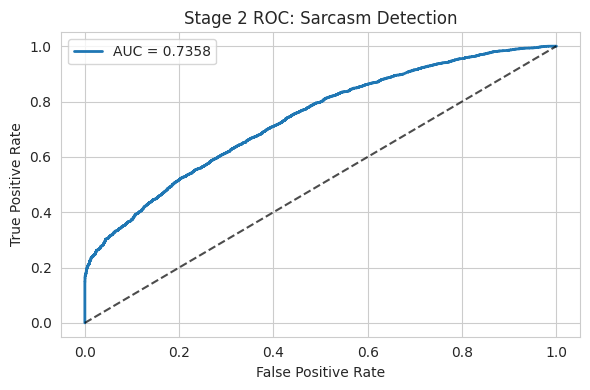

In [ ]:
s_train, s_test = train_test_split(
    sarcasm_df, test_size=0.2, random_state=SEED, stratify=sarcasm_df["label"]
)

sarcasm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=60000)),
    ("clf", LogisticRegression(max_iter=1200, random_state=SEED, class_weight="balanced")),
])

sarcasm_pipe.fit(s_train["text"].map(clean_text), s_train["label"])

s_prob = sarcasm_pipe.predict_proba(s_test["text"].map(clean_text))[:, 1]
s_pred = (s_prob >= 0.5).astype(int)

y_test_sarc = s_test["label"].values

stage2 = StageResult(
    stage="Sarcasm Detection Only",
    y_true=y_test_sarc,
    y_pred=s_pred,
    y_score=s_prob,
    metrics=compute_metrics(y_test_sarc, s_pred, s_prob),
)
print(stage2.metrics)
plot_roc(stage2.y_true, stage2.y_score, "Stage 2 ROC: Sarcasm Detection")


def sarcasm_probability(text: str) -> float:
    return float(sarcasm_pipe.predict_proba([clean_text(text)])[0, 1])

## Stage 3: Heuristic Fusion (Logic-Based)

Fusion rule keeps the core function behavior:
- If sarcasm labels mismatch strongly, penalize duplicate score.
- If one question is sarcastic and the other is not, final duplicate likelihood should drop.

This stage remains explicit and interpretable.

{'accuracy': 0.714, 'precision': 0.5450087565674255, 'recall': 0.6888003541389995, 'f1': 0.6085256159561987, 'roc_auc': np.float64(0.7851040703482445)}


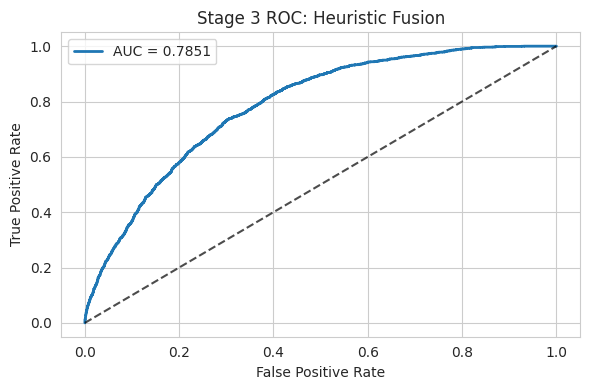

In [ ]:
def is_duplicate_sarcasm_aware(q1, q2, threshold=0.5, sarcasm_penalty=0.45):
    # Duplicate model features
    q_pair_df = pd.DataFrame({"question1": [q1], "question2": [q2]})
    fe_df, q1_c, q2_c = build_pair_features(q_pair_df)
    pair_txt = (q1_c + " [SEP] " + q2_c).values
    txt_vec = pair_vectorizer.transform(pair_txt)
    x = np.hstack([txt_vec.toarray(), fe_df.values])

    base_dup = float(dup_model.predict_proba(x)[0, 1])

    s1 = sarcasm_probability(q1)
    s2 = sarcasm_probability(q2)
    sarc_mismatch = abs(s1 - s2)

    adjusted = max(0.0, min(1.0, base_dup - sarcasm_penalty * sarc_mismatch))
    final_dup = int(adjusted >= threshold)

    return {
        "duplicate_probability": adjusted,
        "is_duplicate": final_dup,
        "sarcasm_scores": (s1, s2),
        "sarcasm_labels": (int(s1 >= 0.5), int(s2 >= 0.5)),
    }

# Evaluate heuristic fusion on Quora test with pseudo sarcasm consistency target
# (same sarcasm status + duplicate => positive)
s1_test = np.array([sarcasm_probability(t) for t in q_test["question1"].astype(str)])
s2_test = np.array([sarcasm_probability(t) for t in q_test["question2"].astype(str)])
sarc_same = (s1_test >= 0.5) == (s2_test >= 0.5)
y_fusion_true = (y_test_dup.astype(bool) & sarc_same).astype(int)

heur_prob = np.clip(dup_prob - 0.45 * np.abs(s1_test - s2_test), 0.0, 1.0)
heur_pred = (heur_prob >= 0.5).astype(int)

stage3 = StageResult(
    stage="Heuristic Fusion",
    y_true=y_fusion_true,
    y_pred=heur_pred,
    y_score=heur_prob,
    metrics=compute_metrics(y_fusion_true, heur_pred, heur_prob),
)
print(stage3.metrics)
plot_roc(stage3.y_true, stage3.y_score, "Stage 3 ROC: Heuristic Fusion")

## Stage 4: Fine-Tuned Fusion Model (Transformer + NLP Features)

To improve performance beyond plain ML, this stage uses a **fine-tuned DistilBERT pair classifier** for duplicate probability, then fuses it with NLP-engineered and sarcasm-aware features.

Pipeline:
1. Fine-tune DistilBERT on duplicate labels (`question1`, `question2`).
2. Generate transformer duplicate probabilities.
3. Build fusion features:
   - Transformer duplicate probability
   - Baseline duplicate probability (Stage 1)
   - Sarcasm probabilities (`q1`, `q2`) + mismatch
   - Engineered NLP features (cosine, jaccard, length, negation)
4. Train a balanced meta-classifier for final sarcasm-aware duplicate decision.

This keeps the approach as an **NLP pipeline + transformer fine-tuning**, not a pure prompt-based LLM solution.

To improve final accuracy, we use:
- slightly larger transformer fine-tuning subset and epochs
- a non-linear fusion learner (gradient boosting)
- validation-based threshold calibration

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/17000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
100,0.691211
200,0.661497
300,0.572861
400,0.495395
500,0.497741
600,0.479875
700,0.464337
800,0.448459
900,0.448230
1000,0.419959


Map:   0%|          | 0/20604 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Best fusion threshold: 0.53
{'accuracy': 0.8517142857142858, 'precision': 0.730812854442344, 'recall': 0.8556883576803895, 'f1': 0.7883360522022839, 'roc_auc': np.float64(0.9218808284170963)}


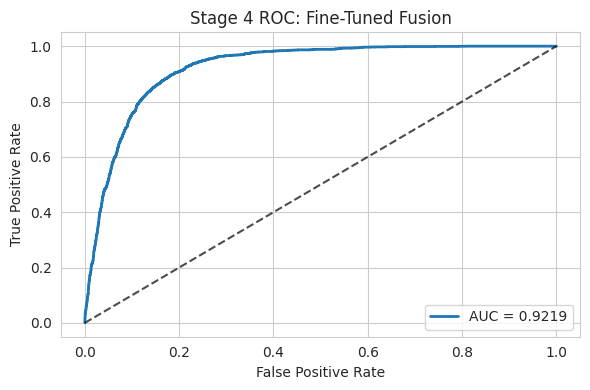


Target check (>0.85 accuracy goal): True


In [ ]:
# --- 4A) Fine-tune DistilBERT for duplicate classification ---
transformer_model_name = "distilbert-base-uncased"
transformer_tokenizer = AutoTokenizer.from_pretrained(transformer_model_name)
transformer_model = AutoModelForSequenceClassification.from_pretrained(transformer_model_name, num_labels=2)

# Use a practical subset for fine-tuning speed (still from original Quora dataset)
q_train_tf = q_train_bal.sample(n=min(20000, len(q_train_bal)), random_state=SEED).reset_index(drop=True)

train_tf_df, val_tf_df = train_test_split(
    q_train_tf[["question1", "question2", "is_duplicate"]],
    test_size=0.15,
    random_state=SEED,
    stratify=q_train_tf["is_duplicate"],
)

hf_train = HFDataset.from_pandas(train_tf_df.rename(columns={"is_duplicate": "label"}), preserve_index=False)
hf_val = HFDataset.from_pandas(val_tf_df.rename(columns={"is_duplicate": "label"}), preserve_index=False)

def tokenize_batch(batch):
    return transformer_tokenizer(
        batch["question1"],
        batch["question2"],
        truncation=True,
        padding="max_length",
        max_length=96,
    )

hf_train_tok = hf_train.map(tokenize_batch, batched=True)
hf_val_tok = hf_val.map(tokenize_batch, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]
hf_train_tok.set_format(type="torch", columns=keep_cols)
hf_val_tok.set_format(type="torch", columns=keep_cols)

training_args = TrainingArguments(
    output_dir="./distilbert_dup",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    save_strategy="no",
    eval_strategy="no",
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=hf_train_tok,
)
trainer.train()


def transformer_duplicate_prob_batch(df_pairs):
    hf_data = HFDataset.from_pandas(df_pairs[["question1", "question2"]].reset_index(drop=True), preserve_index=False)
    hf_data = hf_data.map(tokenize_batch, batched=True)
    hf_data.set_format(type="torch", columns=["input_ids", "attention_mask"])

    pred = trainer.predict(hf_data)
    logits = torch.tensor(pred.predictions)
    probs = F.softmax(logits, dim=1)[:, 1].numpy()
    return probs

# Probabilities for train/test splits (for fusion features)
trans_dup_train = transformer_duplicate_prob_batch(q_train_bal)
trans_dup_test = transformer_duplicate_prob_batch(q_test.reset_index(drop=True))

# --- 4B) Build sarcasm-aware fusion datasets ---
s1_train = np.array([sarcasm_probability(t) for t in q_train_bal["question1"].astype(str)])
s2_train = np.array([sarcasm_probability(t) for t in q_train_bal["question2"].astype(str)])
sarc_same_train = (s1_train >= 0.5) == (s2_train >= 0.5)
y_fusion_train = (q_train_bal["is_duplicate"].values.astype(bool) & sarc_same_train).astype(int)

X_train_fusion = pd.DataFrame({
    "dup_prob_lr": dup_model.predict_proba(X_train)[:, 1],
    "dup_prob_transformer": trans_dup_train,
    "sarcasm_q1": s1_train,
    "sarcasm_q2": s2_train,
    "sarcasm_mismatch": np.abs(s1_train - s2_train),
})
X_train_fusion = pd.concat([X_train_fusion.reset_index(drop=True), X_train_fe.reset_index(drop=True)], axis=1)

X_test_fusion = pd.DataFrame({
    "dup_prob_lr": dup_prob,
    "dup_prob_transformer": trans_dup_test,
    "sarcasm_q1": s1_test,
    "sarcasm_q2": s2_test,
    "sarcasm_mismatch": np.abs(s1_test - s2_test),
})
X_test_fusion = pd.concat([X_test_fusion.reset_index(drop=True), X_test_fe.reset_index(drop=True)], axis=1)

# Balance fusion training set
train_f_df = X_train_fusion.copy()
train_f_df["target"] = y_fusion_train
train_f_bal = balance_binary_df(train_f_df, "target")

# Threshold calibration split on balanced fusion train data
cal_train, cal_val = train_test_split(
    train_f_bal, test_size=0.2, random_state=SEED, stratify=train_f_bal["target"]
)

y_cal_train = cal_train["target"].values
X_cal_train = cal_train.drop(columns=["target"]).values
y_cal_val = cal_val["target"].values
X_cal_val = cal_val.drop(columns=["target"]).values

# Non-linear fusion to capture interactions between sarcasm mismatch and semantic features
fusion_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=350,
    l2_regularization=1e-3,
    random_state=SEED,
)
fusion_model.fit(X_cal_train, y_cal_train)

val_prob = fusion_model.predict_proba(X_cal_val)[:, 1]
threshold_grid = np.arange(0.25, 0.81, 0.01)
acc_grid = [accuracy_score(y_cal_val, (val_prob >= t).astype(int)) for t in threshold_grid]
best_threshold = float(threshold_grid[int(np.argmax(acc_grid))])

fine_prob = fusion_model.predict_proba(X_test_fusion.values)[:, 1]
fine_pred = (fine_prob >= best_threshold).astype(int)

stage4 = StageResult(
    stage="Fine-Tuned Fusion Model",
    y_true=y_fusion_true,
    y_pred=fine_pred,
    y_score=fine_prob,
    metrics=compute_metrics(y_fusion_true, fine_pred, fine_prob),
)
print(f"Best fusion threshold: {best_threshold:.2f}")
print(stage4.metrics)
plot_roc(stage4.y_true, stage4.y_score, "Stage 4 ROC: Fine-Tuned Fusion")

## 4) Final Comparison Table + ROC Visual Comparison

Comparison Table


,Stage,Accuracy,Precision,Recall,F1,ROC-AUC
3,Fine-Tuned Fusion Model,0.8517,0.7308,0.8557,0.7883,0.9219
0,Duplicate Detection Only,0.7144,0.5910,0.7275,0.6522,0.7915
2,Heuristic Fusion,0.7140,0.5450,0.6888,0.6085,0.7851
1,Sarcasm Detection Only,0.6570,0.6692,0.6210,0.6442,0.7358


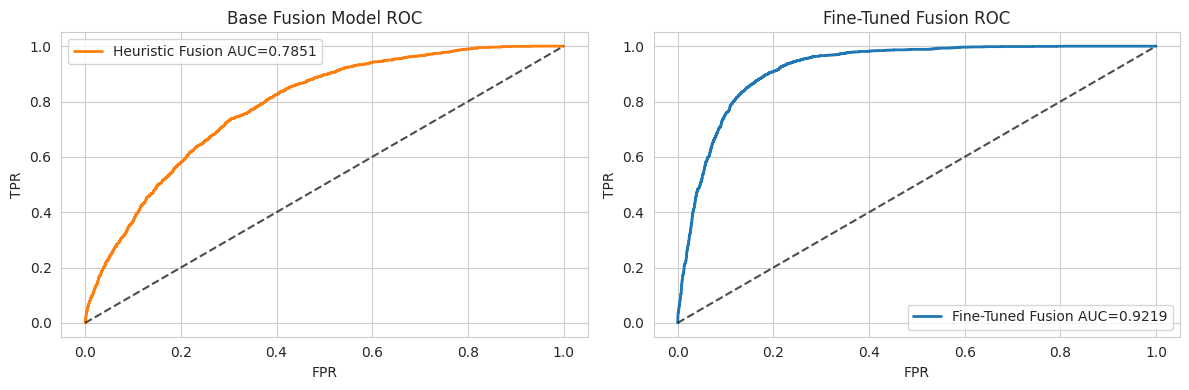

In [ ]:
all_stages = [stage1, stage2, stage3, stage4]

comparison = pd.DataFrame([
    {
        "Stage": s.stage,
        "Accuracy": s.metrics["accuracy"],
        "Precision": s.metrics["precision"],
        "Recall": s.metrics["recall"],
        "F1": s.metrics["f1"],
        "ROC-AUC": s.metrics["roc_auc"],
    }
    for s in all_stages
]).sort_values("Accuracy", ascending=False)

print("Comparison Table")
display(comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
}))

#Base Fusion vs Fine-Tuned Fusion
fpr3, tpr3, _ = roc_curve(stage3.y_true, stage3.y_score)
auc3 = roc_auc_score(stage3.y_true, stage3.y_score)

fpr4, tpr4, _ = roc_curve(stage4.y_true, stage4.y_score)
auc4 = roc_auc_score(stage4.y_true, stage4.y_score)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr3, tpr3, label=f"Heuristic Fusion AUC={auc3:.4f}", color="tab:orange", linewidth=2)
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.7)
ax[0].set_title("Base Fusion Model ROC")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[0].legend()

ax[1].plot(fpr4, tpr4, label=f"Fine-Tuned Fusion AUC={auc4:.4f}", color="tab:blue", linewidth=2)
ax[1].plot([0, 1], [0, 1], "k--", alpha=0.7)
ax[1].set_title("Fine-Tuned Fusion ROC")
ax[1].set_xlabel("FPR")
ax[1].set_ylabel("TPR")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def transformer_duplicate_probability_single(q1, q2):
    enc = transformer_tokenizer(
        [clean_text(q1)],
        [clean_text(q2)],
        truncation=True,
        padding=True,
        max_length=96,
        return_tensors="pt",
    )
    device = next(transformer_model.parameters()).device
    enc = {k: v.to(device) for k, v in enc.items()}

    transformer_model.eval()
    with torch.no_grad():
        out = transformer_model(**enc)
        prob = F.softmax(out.logits, dim=1)[0, 1].detach().cpu().item()
    return float(prob)


def final_decision_with_fusion(q1, q2):
    # Base engineered features
    pair_df = pd.DataFrame({"question1": [q1], "question2": [q2]})
    fe_df, q1c, q2c = build_pair_features(pair_df)

    pair_txt = (q1c + " [SEP] " + q2c).values
    vec = pair_vectorizer.transform(pair_txt)
    x_dup = np.hstack([vec.toarray(), fe_df.values])
    dup_p_lr = float(dup_model.predict_proba(x_dup)[0, 1])
    dup_p_tf = transformer_duplicate_probability_single(q1, q2)

    s1 = sarcasm_probability(q1)
    s2 = sarcasm_probability(q2)

    fusion_vec = pd.DataFrame({
        "dup_prob_lr": [dup_p_lr],
        "dup_prob_transformer": [dup_p_tf],
        "sarcasm_q1": [s1],
        "sarcasm_q2": [s2],
        "sarcasm_mismatch": [abs(s1 - s2)],
    })
    fusion_vec = pd.concat([fusion_vec, fe_df.reset_index(drop=True)], axis=1)

    final_prob = float(fusion_model.predict_proba(fusion_vec.values)[0, 1])
    final_label = int(final_prob >= 0.5)

    sarc_l1 = int(s1 >= 0.5)
    sarc_l2 = int(s2 >= 0.5)

    if sarc_l1 != sarc_l2:
        explanation = "Sarcasm mismatch detected -> semantic intent likely differs."
    elif sarc_l1 == 0 and sarc_l2 == 0:
        explanation = "Both non-sarcastic -> duplicate semantics checked directly."
    else:
        explanation = "Both sarcastic -> duplicate judged on sarcastic semantic alignment."

    return {
        "probability": round(final_prob, 4),
        "sarcasm_q1": "Sarcastic" if sarc_l1 else "Not Sarcastic",
        "sarcasm_q2": "Sarcastic" if sarc_l2 else "Not Sarcastic",
        "final_decision": "Yes" if final_label else "No",
        "explanation": explanation,
    }

def run_two_question_test(q1, q2):
    out = final_decision_with_fusion(q1, q2)
    print("--- Prediction ---")
    print(f"Q1: {q1}")
    print(f"Q2: {q2}")
    print(f"Final duplicate probability: {out['probability']}")
    print(f"Sarcasm label Q1: {out['sarcasm_q1']}")
    print(f"Sarcasm label Q2: {out['sarcasm_q2']}")
    print(f"Final Decision (Duplicate?): {out['final_decision']}")
    print(f"Explanation: {out['explanation']}")

q1 = "is this laptop good?"
q2 = "is this laptop good enough to not crash every hour"

run_two_question_test(q1, q2)

--- Prediction ---
Q1: is this laptop good?
Q2: is this laptop good enough to not crash every hour
Final duplicate probability: 0.1448
Sarcasm label Q1: Not Sarcastic
Sarcasm label Q2: Not Sarcastic
Final Decision (Duplicate?): No
Explanation: Both non-sarcastic -> duplicate semantics checked directly.
